In [1]:
import pandas as pd

# Load NAV data
nav = pd.read_csv("../data/processed/nav_history_clean.csv")

# Convert date
nav["date"] = pd.to_datetime(nav["date"])

# Sort properly
nav = nav.sort_values(["amfi_code", "date"])

# Compute daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

print(nav[["amfi_code", "date", "nav", "daily_return"]].head(10))

   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
5     100016 2022-01-10  510.7136     -0.008639
6     100016 2022-01-11  513.5542      0.005562
7     100016 2022-01-12  512.3195     -0.002404
8     100016 2022-01-13  510.2445     -0.004050
9     100016 2022-01-14  514.3636      0.008073


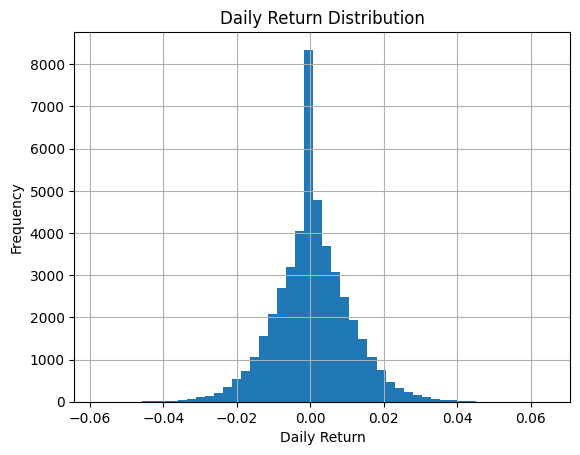

In [2]:
import matplotlib.pyplot as plt

nav["daily_return"].hist(bins=50)

plt.title("Daily Return Distribution")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

In [3]:
nav.to_csv("../data/processed/nav_daily_returns.csv", index=False)

print("Saved Successfully")

Saved Successfully


CAGR Calculation (1-Year, 3-Year, 5-Year)

In [4]:
import pandas as pd

nav = pd.read_csv("../data/processed/nav_history_clean.csv")
nav["date"] = pd.to_datetime(nav["date"])

results = []

for code in nav["amfi_code"].unique():

    fund = nav[nav["amfi_code"] == code].sort_values("date")

    nav_start = fund.iloc[0]["nav"]
    nav_end = fund.iloc[-1]["nav"]

    years = (
        (fund.iloc[-1]["date"] - fund.iloc[0]["date"]).days
    ) / 365.25

    cagr = ((nav_end / nav_start) ** (1 / years) - 1) * 100

    results.append([code, round(cagr, 2)])

cagr_df = pd.DataFrame(
    results,
    columns=["amfi_code", "CAGR_%"]
)

cagr_df = cagr_df.sort_values(
    "CAGR_%",
    ascending=False
)

cagr_df.head()

,amfi_code,CAGR_%
25,120505,32.83
21,119598,32.42
39,149324,32.29
36,148569,31.95
34,148567,30.97
